# Pipe End YOLO - cam151 + cam152

Notebook de integracion para correr el mismo modelo YOLO `pipe_end` sobre los warps de `cam151` y `cam152`.

Objetivo actual: probar una forma de alinear verticalmente los tubos entre ambas camaras.

La deteccion YOLO se usa para ubicar el final visible del tubo cuando el modelo tenga suficiente cobertura. Para la alineacion vertical, por defecto usamos `classic_rows`: filas/centros de tubos estimados por el detector clasico en ambos warps. Esto permite comparar `cam151` y `cam152` aunque YOLO todavia no detecte bien `cam152`.


In [48]:
from __future__ import annotations

import json
import re
import tomllib
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pipe_end_detection').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('No pude encontrar la raiz del repo cam151_ref_detection_clean.')


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipe_end_detection.capture_pipe_end_dataset import build_warp_for_camera  # noqa: E402
from src.cam151_ref_detection.capture_history import default_roi_paths  # noqa: E402
from src.tenaris_tube_pipeline.notebook_style_detection import _detect_notebook_positions  # noqa: E402

CAPTURE_RUNS_DIR = ROOT / 'pipe_end_detection' / 'captures' / 'runs'
ARTIFACT_DIR = ROOT / 'artifacts' / 'pipe_end_yolo_notebook'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ROOT / 'pipe_end_detection' / 'models' / 'pipe_end_active' / 'best.pt'
FALLBACK_MODEL_PATH = Path(r'C:\Users\luis_\Downloads\pipe_end_yolo_project\models\pipe_end_active\best.pt')
if not MODEL_PATH.exists() and FALLBACK_MODEL_PATH.exists():
    MODEL_PATH = FALLBACK_MODEL_PATH

# Cambia RUN_ID para procesar una corrida especifica. None toma la mas reciente.
RUN_ID = "20260506_233156"

# Regenerar warps con los ROI defaults actuales. Mantener True para que coincida con el modelo entrenado actual.
REGENERATE_WARPS = True

CONF = 0.20
IMGSZ = 1280
DEVICE = 0  # usa GPU si torch/ultralytics la ve; cambia a 'cpu' si hace falta.

# Para alinear tubos ahora usamos filas clasicas. Opciones: 'classic_rows', 'yolo', 'auto'.
ALIGNMENT_SOURCE = 'classic_rows'
MIN_YOLO_ALIGNMENT_COUNT = 8

# Ajuste temporal para probar si el crop/warp de cam152 esta movido.
# Valores positivos mueven la ventana dst_rect en coordenadas warp.
# No modifica el TOML default a menos que ejecutes la celda de guardado al final.
CAM152_TEST_DX = 0.0
CAM152_TEST_DY = 0.0

print('ROOT =', ROOT)
print('MODEL_PATH =', MODEL_PATH)
print('CAPTURE_RUNS_DIR =', CAPTURE_RUNS_DIR)


ROOT = C:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean
MODEL_PATH = C:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\pipe_end_detection\models\pipe_end_active\best.pt
CAPTURE_RUNS_DIR = C:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\pipe_end_detection\captures\runs


In [49]:
def has_raw_pair(run_dir: Path) -> bool:
    raw_dir = run_dir / 'raw'
    cam151 = [p for p in raw_dir.glob('cam_151_*.*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}]
    cam152 = [p for p in raw_dir.glob('cam_152_*.*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}]
    return bool(cam151 and cam152)


def list_capture_runs(limit: int | None = 25, *, only_valid: bool = True) -> list[Path]:
    if not CAPTURE_RUNS_DIR.exists():
        return []
    runs = [p for p in CAPTURE_RUNS_DIR.iterdir() if p.is_dir()]
    if only_valid:
        runs = [p for p in runs if has_raw_pair(p)]
    runs = sorted(runs, key=lambda p: p.name, reverse=True)
    return runs if limit is None else runs[:limit]


all_valid_runs = list_capture_runs(None)
runs_preview = all_valid_runs[:25]
print(f'Total runs validos con raw cam151+cam152: {len(all_valid_runs)}')
print(f'Mostrando primeros: {len(runs_preview)}')
for path in runs_preview:
    print('-', path.name)

if RUN_ID is None:
    if not all_valid_runs:
        raise FileNotFoundError('No hay corridas en pipe_end_detection/captures/runs.')
    RUN_ID = all_valid_runs[0].name

RUN_DIR = CAPTURE_RUNS_DIR / RUN_ID
print('\nRUN_ID seleccionado =', RUN_ID)
print('RUN_DIR =', RUN_DIR)


Total runs validos con raw cam151+cam152: 111
Mostrando primeros: 25
- 20260508_001600
- 20260507_224513
- 20260507_211455
- 20260507_194430
- 20260507_181331
- 20260507_164245
- 20260507_134159
- 20260507_010220
- 20260506_233156
- 20260506_220107
- 20260506_203034
- 20260506_185957
- 20260506_172938
- 20260506_155911
- 20260506_142846
- 20260506_125802
- 20260506_112218
- 20260506_094623
- 20260506_081100
- 20260506_063529
- 20260506_050506
- 20260506_033439
- 20260506_020425
- 20260506_003411
- 20260505_230343

RUN_ID seleccionado = 20260506_233156
RUN_DIR = C:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\pipe_end_detection\captures\runs\20260506_233156


In [50]:
def repo_rel(path: Path) -> str:
    try:
        return str(path.resolve().relative_to(ROOT.resolve())).replace('\\', '/')
    except Exception:
        return str(path)


def resolve_repo_path(value: str | Path) -> Path:
    path = Path(value)
    return path if path.is_absolute() else ROOT / path


def load_manifest(run_dir: Path) -> dict:
    manifest_path = run_dir / 'manifest.json'
    if not manifest_path.exists():
        return {}
    return json.loads(manifest_path.read_text(encoding='utf-8'))


def roi_path_with_dst_offset(side: str, roi_path: Path) -> Path:
    if str(side) != '152' or (abs(float(CAM152_TEST_DX)) < 1e-9 and abs(float(CAM152_TEST_DY)) < 1e-9):
        return roi_path
    data = tomllib.loads(roi_path.read_text(encoding='utf-8'))
    rect = [float(v) for v in data['dst_rect_override']]
    adjusted = [rect[0] + float(CAM152_TEST_DX), rect[1] + float(CAM152_TEST_DY), rect[2] + float(CAM152_TEST_DX), rect[3] + float(CAM152_TEST_DY)]
    text = roi_path.read_text(encoding='utf-8')
    replacement = 'dst_rect_override = [' + ', '.join(f'{v:.3f}' for v in adjusted) + ']'
    adjusted_text = re.sub(r'dst_rect_override\s*=\s*\[[^\]]+\]', replacement, text, count=1)
    out_path = ARTIFACT_DIR / RUN_ID / 'cam152_test_roi_offset.toml'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(adjusted_text, encoding='utf-8')
    print('cam152 dst_rect original =', [round(v, 3) for v in rect])
    print('cam152 dst_rect test     =', [round(v, 3) for v in adjusted])
    print('cam152 test ROI path     =', out_path)
    return out_path


def raw_image_for_side(run_dir: Path, side: str, run_id: str) -> Path:
    raw_dir = run_dir / 'raw'
    candidates = sorted(raw_dir.glob(f'cam_{side}_{run_id}.*'))
    if not candidates:
        candidates = sorted(raw_dir.glob(f'*{side}*.*'))
    candidates = [p for p in candidates if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}]
    if not candidates:
        raise FileNotFoundError(f'No encontre raw image para cam{side} en {raw_dir}')
    return candidates[0]


def warp_for_side(run_dir: Path, side: str, run_id: str, *, regenerate: bool = True) -> dict:
    manifest = load_manifest(run_dir)
    camera_key = f'cam{side}'
    if not regenerate:
        warp_info = (manifest.get('homography') or {}).get(camera_key) or {}
        warp_path_value = warp_info.get('warp_path')
        if warp_path_value:
            warp_path = resolve_repo_path(warp_path_value)
            if warp_path.exists():
                return {'side': side, 'warp_path': warp_path, 'source': 'manifest', 'info': warp_info}

    roi_path = roi_path_with_dst_offset(side, default_roi_paths()[side])
    raw_path = raw_image_for_side(run_dir, side, run_id)
    work_root = ARTIFACT_DIR / run_id / f'cam{side}'
    warp_info = build_warp_for_camera(
        side=side,
        image_path=raw_path,
        roi_path=roi_path,
        work_dir=work_root / '_homography_work',
        warp_dir=work_root / 'warped',
        overlay_dir=work_root / 'overlays',
        run_id=run_id,
    )
    warp_path = resolve_repo_path(warp_info['warp_path'])
    return {'side': side, 'warp_path': warp_path, 'source': 'regenerated', 'info': warp_info}


warps = {side: warp_for_side(RUN_DIR, side, RUN_ID, regenerate=REGENERATE_WARPS) for side in ('151', '152')}
for side, payload in warps.items():
    image = cv2.imread(str(payload['warp_path']), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(payload['warp_path'])
    print(f"cam{side}: {payload['source']} | {payload['warp_path']} | shape={image.shape}")


cam151: regenerated | C:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\artifacts\pipe_end_yolo_notebook\20260506_233156\cam151\warped\cam_151_20260506_233156_warp.jpg | shape=(1502, 1186, 3)
cam152: regenerated | C:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\artifacts\pipe_end_yolo_notebook\20260506_233156\cam152\warped\cam_152_20260506_233156_warp.jpg | shape=(1212, 667, 3)


In [51]:
def detections_from_result(result) -> list[dict]:
    detections: list[dict] = []
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return detections
    xyxy = boxes.xyxy.detach().cpu().numpy()
    conf = boxes.conf.detach().cpu().numpy()
    cls = boxes.cls.detach().cpu().numpy().astype(int)
    for index, (box, score, class_id) in enumerate(zip(xyxy, conf, cls), start=1):
        x1, y1, x2, y2 = [float(v) for v in box]
        detections.append({
            'index': int(index),
            'class_id': int(class_id),
            'class_name': 'pipe_end' if int(class_id) == 0 else str(class_id),
            'confidence': float(score),
            'xyxy': [x1, y1, x2, y2],
            'center_xy': [0.5 * (x1 + x2), 0.5 * (y1 + y2)],
            'width': float(x2 - x1),
            'height': float(y2 - y1),
        })
    return sorted(detections, key=lambda d: (d['center_xy'][1], d['center_xy'][0]))


def draw_detections(image_bgr: np.ndarray, detections: list[dict]) -> np.ndarray:
    vis = image_bgr.copy()
    for idx, det in enumerate(detections, start=1):
        x1, y1, x2, y2 = [int(round(v)) for v in det['xyxy']]
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 230, 255), 2, cv2.LINE_AA)
        cv2.putText(vis, str(idx), (x1, max(0, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 2, cv2.LINE_AA)
        cv2.putText(vis, str(idx), (x1, max(0, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
    return vis


if not MODEL_PATH.exists():
    raise FileNotFoundError(f'No existe el modelo: {MODEL_PATH}')

model = YOLO(str(MODEL_PATH))
source_paths = [str(warps[side]['warp_path']) for side in ('151', '152')]
results = model.predict(source=source_paths, imgsz=IMGSZ, conf=CONF, device=DEVICE, verbose=False)

predictions = {}
for side, result in zip(('151', '152'), results):
    image_bgr = cv2.imread(str(warps[side]['warp_path']), cv2.IMREAD_COLOR)
    detections = detections_from_result(result)
    predictions[side] = {
        'side': side,
        'warp_path': warps[side]['warp_path'],
        'detections': detections,
        'vis_bgr': draw_detections(image_bgr, detections),
    }
    print(f'cam{side}: {len(detections)} pipe_end detections')


cam151: 0 pipe_end detections
cam152: 0 pipe_end detections


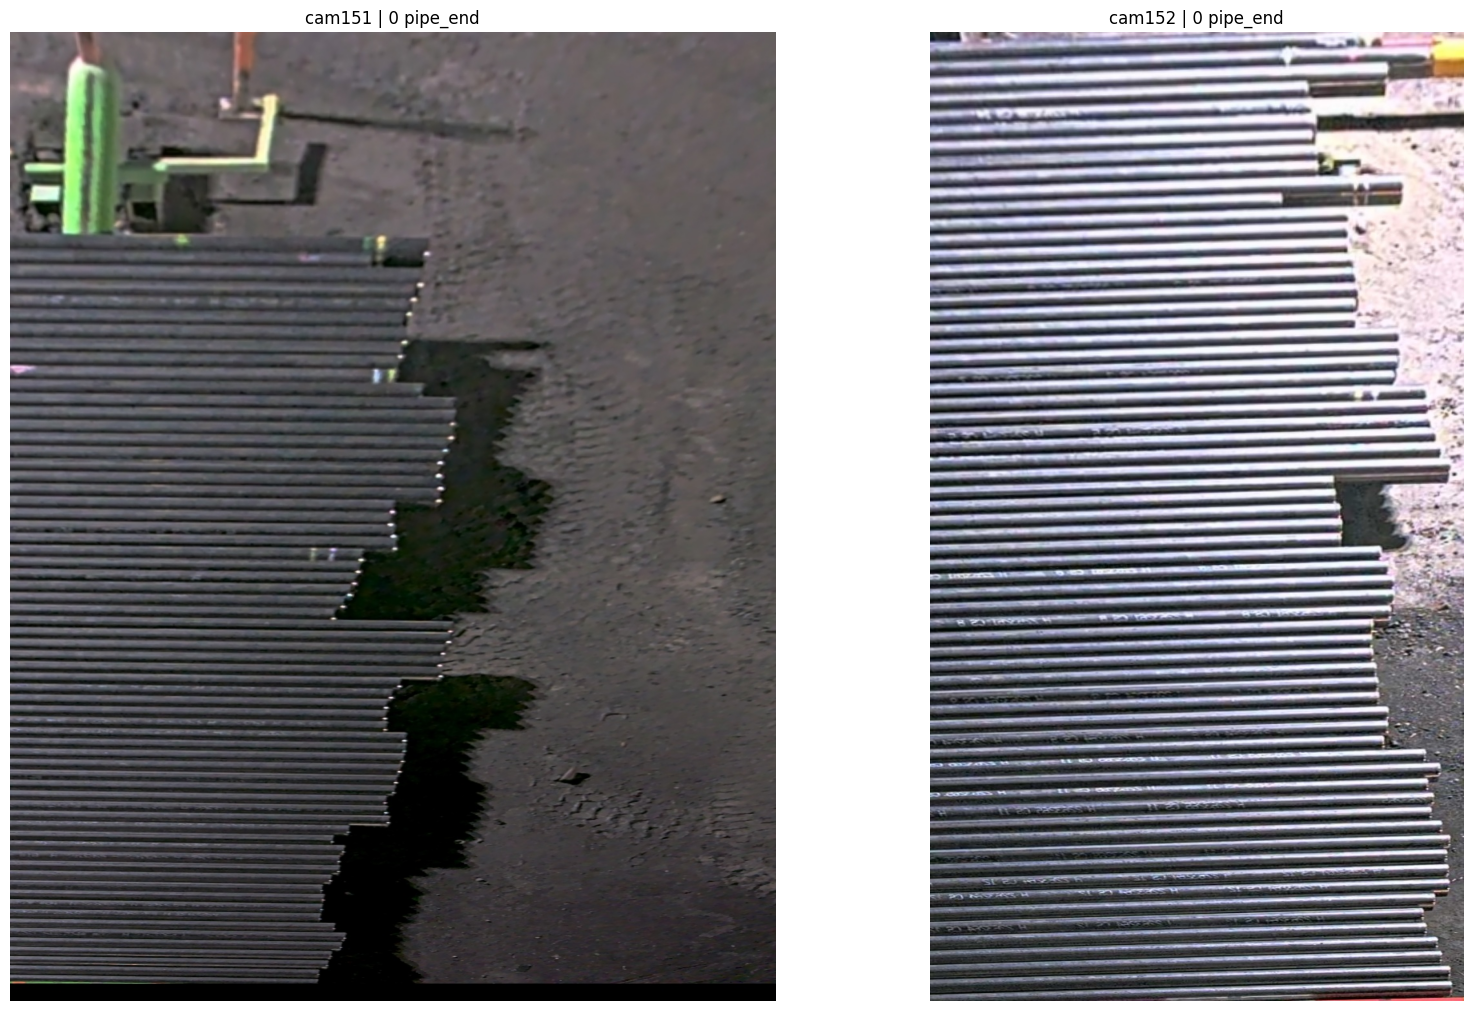

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10), constrained_layout=True)
for ax, side in zip(axes, ('151', '152')):
    vis_rgb = cv2.cvtColor(predictions[side]['vis_bgr'], cv2.COLOR_BGR2RGB)
    ax.imshow(vis_rgb)
    ax.set_title(f"cam{side} | {len(predictions[side]['detections'])} pipe_end")
    ax.axis('off')
plt.show()


## Alineacion vertical entre camaras

Idea inicial: usar la posicion vertical (`y_center`) de cada `pipe_end`, ordenar de arriba hacia abajo, ajustar una transformacion afin `y_cam151 = a * y_cam152 + b`, y luego hacer matching monotono. Esto permite ver si ambos lados estan detectando el mismo tubo en la misma altura relativa.

In [53]:
def sorted_pipe_ends(side: str, min_conf: float = CONF) -> list[dict]:
    dets = [d for d in predictions[side]['detections'] if d['class_id'] == 0 and d['confidence'] >= min_conf]
    out = []
    for det in sorted(dets, key=lambda d: (d['center_xy'][1], d['center_xy'][0])):
        cloned = dict(det)
        cloned['source'] = 'yolo_pipe_end'
        out.append(cloned)
    return out


def classic_tube_rows(side: str) -> list[dict]:
    """Return tube row tracks from the notebook-style detector on the full warp.

    This is intentionally used for vertical alignment because it depends on the
    horizontal tube stack structure, not on YOLO endpoint quality.
    """
    image_bgr = cv2.imread(str(warps[side]['warp_path']), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(warps[side]['warp_path'])
    summary = _detect_notebook_positions(image_bgr)
    rows = []
    for idx, item in enumerate(summary.get('x_start_list') or [], start=1):
        x = float(item.get('x_start_smooth', item.get('x_start', 0.0)))
        y = float(item.get('y_center', 0.0))
        rows.append({
            'index': int(idx),
            'tube_idx': int(item.get('tube_idx', idx)),
            'class_id': 0,
            'class_name': 'tube_row',
            'source': 'classic_rows',
            'confidence': float(item.get('confidence', 1.0)),
            'xyxy': [x - 4.0, y - 4.0, x + 4.0, y + 4.0],
            'center_xy': [x, y],
            'width': 8.0,
            'height': 8.0,
        })
    rows = sorted(rows, key=lambda d: (d['center_xy'][1], d['center_xy'][0]))
    return rows


def alignment_tracks_for_side(side: str) -> list[dict]:
    yolo_tracks = sorted_pipe_ends(side)
    classic_tracks = classic_tube_rows(side)
    if ALIGNMENT_SOURCE == 'yolo':
        return yolo_tracks
    if ALIGNMENT_SOURCE == 'classic_rows':
        return classic_tracks
    if ALIGNMENT_SOURCE == 'auto':
        return yolo_tracks if len(yolo_tracks) >= MIN_YOLO_ALIGNMENT_COUNT else classic_tracks
    raise ValueError(f'ALIGNMENT_SOURCE no soportado: {ALIGNMENT_SOURCE}')


def fit_vertical_affine(reference_y: np.ndarray, moving_y: np.ndarray) -> tuple[float, float, list[tuple[int, int]]]:
    n = int(min(reference_y.size, moving_y.size))
    if n < 2:
        return 1.0, 0.0, []
    ref_idx = np.rint(np.linspace(0, reference_y.size - 1, n)).astype(int)
    mov_idx = np.rint(np.linspace(0, moving_y.size - 1, n)).astype(int)
    ref_sample = reference_y[ref_idx]
    mov_sample = moving_y[mov_idx]
    a, b = np.polyfit(mov_sample, ref_sample, 1)
    return float(a), float(b), [(int(i), int(j)) for i, j in zip(ref_idx.tolist(), mov_idx.tolist())]


def ordered_vertical_match(reference: list[dict], moving: list[dict], a: float, b: float) -> list[dict]:
    ref_y = np.asarray([d['center_xy'][1] for d in reference], np.float32)
    mov_y_raw = np.asarray([d['center_xy'][1] for d in moving], np.float32)
    mov_y = (a * mov_y_raw) + b
    if ref_y.size >= 2:
        pitch = float(np.median(np.diff(np.sort(ref_y))))
    else:
        pitch = 20.0
    max_gap = max(10.0, 0.55 * pitch)
    gap_cost = max_gap * 0.85
    n, m = len(reference), len(moving)
    dp = np.zeros((n + 1, m + 1), np.float32)
    back = np.empty((n + 1, m + 1), object)
    for i in range(1, n + 1):
        dp[i, 0] = dp[i - 1, 0] + gap_cost
        back[i, 0] = 'ref_gap'
    for j in range(1, m + 1):
        dp[0, j] = dp[0, j - 1] + gap_cost
        back[0, j] = 'mov_gap'
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            diff = abs(float(ref_y[i - 1]) - float(mov_y[j - 1]))
            match_cost = dp[i - 1, j - 1] + min(diff, 3.0 * max_gap)
            skip_ref = dp[i - 1, j] + gap_cost
            skip_mov = dp[i, j - 1] + gap_cost
            best = min(match_cost, skip_ref, skip_mov)
            dp[i, j] = best
            back[i, j] = 'match' if best == match_cost else 'ref_gap' if best == skip_ref else 'mov_gap'
    pairs = []
    i, j = n, m
    while i > 0 or j > 0:
        step = back[i, j]
        if step == 'match':
            dy = float(ref_y[i - 1] - mov_y[j - 1])
            if abs(dy) <= max_gap:
                pairs.append({
                    'cam151_index': int(i),
                    'cam152_index': int(j),
                    'cam151_detection': reference[i - 1],
                    'cam152_detection': moving[j - 1],
                    'cam151_y': float(ref_y[i - 1]),
                    'cam152_y_raw': float(mov_y_raw[j - 1]),
                    'cam152_y_aligned_to_cam151': float(mov_y[j - 1]),
                    'dy_px': dy,
                    'max_gap_px': float(max_gap),
                })
            i -= 1
            j -= 1
        elif step == 'ref_gap':
            i -= 1
        else:
            j -= 1
    return list(reversed(pairs))


cam151_tracks = alignment_tracks_for_side('151')
cam152_tracks = alignment_tracks_for_side('152')
y151 = np.asarray([d['center_xy'][1] for d in cam151_tracks], np.float32)
y152 = np.asarray([d['center_xy'][1] for d in cam152_tracks], np.float32)
a_y, b_y, rank_seed_pairs = fit_vertical_affine(y151, y152)
vertical_matches = ordered_vertical_match(cam151_tracks, cam152_tracks, a_y, b_y)

alignment = {
    'reference_camera': 'cam151',
    'moving_camera': 'cam152',
    'alignment_source': ALIGNMENT_SOURCE,
    'model': 'y_cam151 = a * y_cam152 + b',
    'a': float(a_y),
    'b': float(b_y),
    'cam151_count': len(cam151_tracks),
    'cam152_count': len(cam152_tracks),
    'matched_count': len(vertical_matches),
    'rank_seed_pairs': rank_seed_pairs,
    'matches': vertical_matches,
}

print(f'ALIGNMENT_SOURCE = {ALIGNMENT_SOURCE}')
print(f'cam151 tracks: {len(cam151_tracks)} source={cam151_tracks[0]["source"] if cam151_tracks else "none"}')
print(f'cam152 tracks: {len(cam152_tracks)} source={cam152_tracks[0]["source"] if cam152_tracks else "none"}')
print(f'y_cam151 = {a_y:.6f} * y_cam152 + {b_y:.2f}')
print(f'matched vertical pairs: {len(vertical_matches)}')
for item in vertical_matches[:30]:
    print(
        f"151#{item['cam151_index']:02d} <-> 152#{item['cam152_index']:02d} "
        f"dy={item['dy_px']:+.1f}px "
        f"src=({item['cam151_detection']['source']},{item['cam152_detection']['source']})"
    )


ALIGNMENT_SOURCE = classic_rows
cam151 tracks: 60 source=classic_rows
cam152 tracks: 59 source=classic_rows
y_cam151 = 1.224320 * y_cam152 + 2.39
matched vertical pairs: 51
151#01 <-> 152#01 dy=+8.0px src=(classic_rows,classic_rows)
151#02 <-> 152#02 dy=+7.3px src=(classic_rows,classic_rows)
151#03 <-> 152#03 dy=-4.5px src=(classic_rows,classic_rows)
151#04 <-> 152#04 dy=+11.8px src=(classic_rows,classic_rows)
151#05 <-> 152#05 dy=+6.9px src=(classic_rows,classic_rows)
151#06 <-> 152#07 dy=-2.4px src=(classic_rows,classic_rows)
151#07 <-> 152#08 dy=+0.5px src=(classic_rows,classic_rows)
151#09 <-> 152#10 dy=+2.8px src=(classic_rows,classic_rows)
151#10 <-> 152#11 dy=-7.0px src=(classic_rows,classic_rows)
151#11 <-> 152#12 dy=-5.1px src=(classic_rows,classic_rows)
151#12 <-> 152#13 dy=-9.0px src=(classic_rows,classic_rows)
151#13 <-> 152#14 dy=-7.8px src=(classic_rows,classic_rows)
151#15 <-> 152#15 dy=+10.0px src=(classic_rows,classic_rows)
151#16 <-> 152#16 dy=-4.3px src=(classic_rows

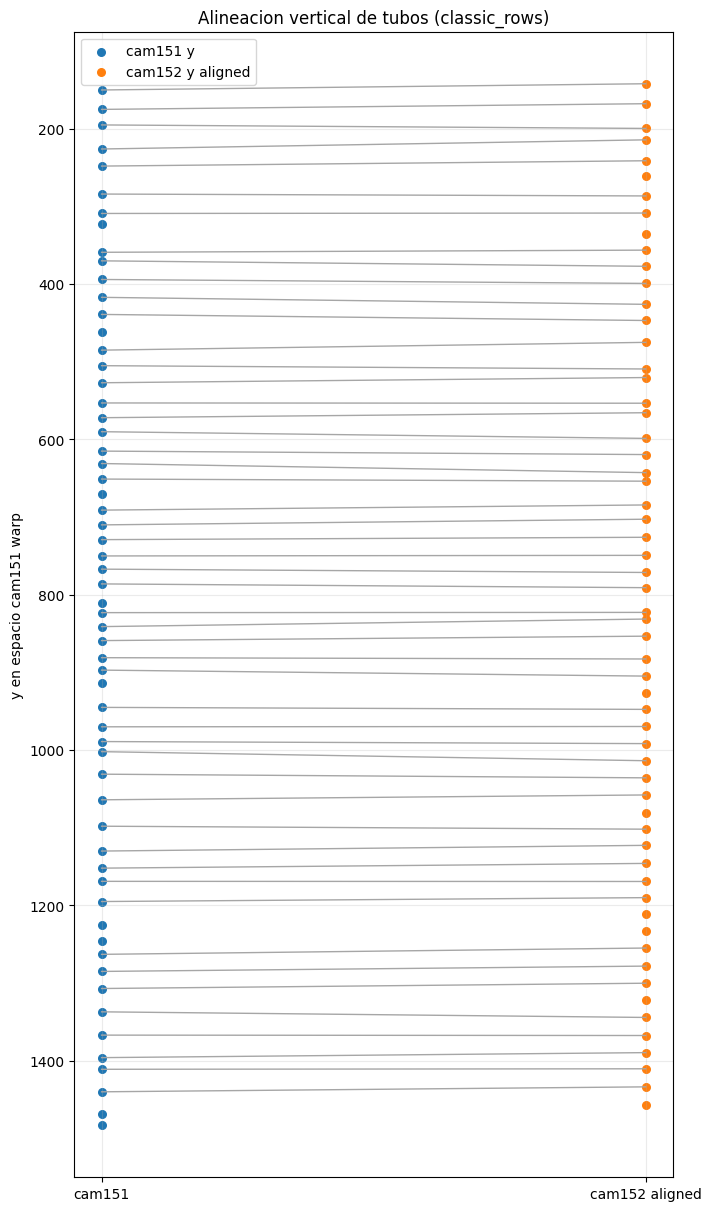

In [54]:
fig, ax = plt.subplots(figsize=(7, 12), constrained_layout=True)
if y151.size:
    ax.scatter(np.zeros_like(y151), y151, s=30, label='cam151 y', color='tab:blue')
if y152.size:
    y152_aligned = (a_y * y152) + b_y
    ax.scatter(np.ones_like(y152_aligned), y152_aligned, s=30, label='cam152 y aligned', color='tab:orange')
for match in vertical_matches:
    ax.plot([0, 1], [match['cam151_y'], match['cam152_y_aligned_to_cam151']], color='0.65', lw=1)
ax.set_xticks([0, 1], ['cam151', 'cam152 aligned'])
ax.set_ylabel('y en espacio cam151 warp')
ax.set_title(f'Alineacion vertical de tubos ({ALIGNMENT_SOURCE})')
ax.invert_yaxis()
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


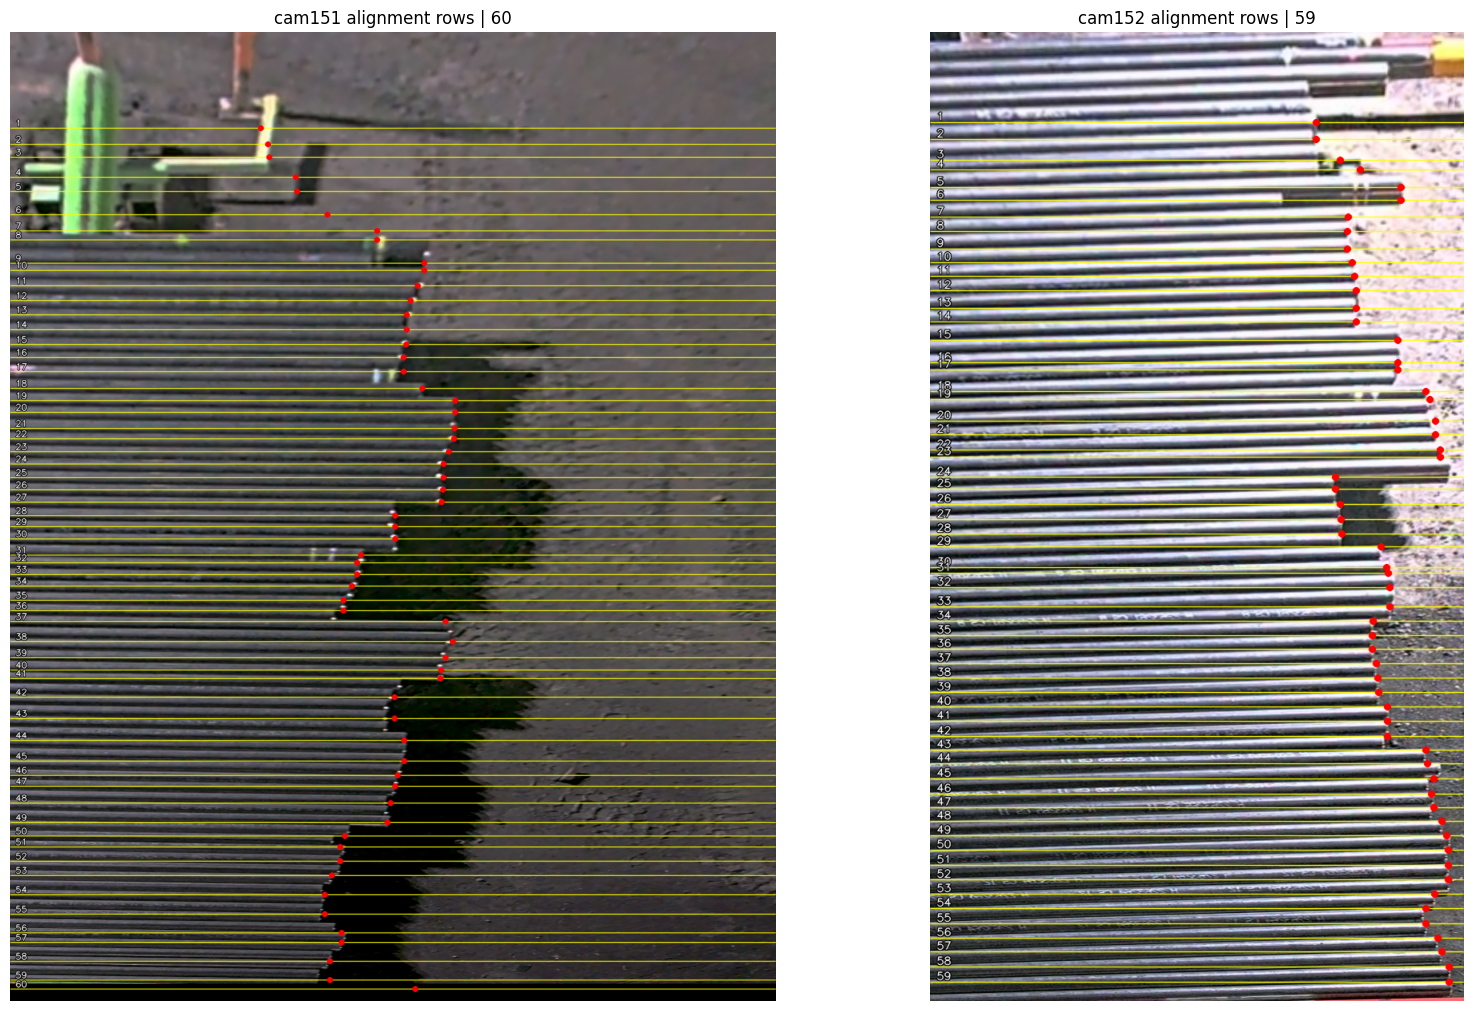

In [55]:
def draw_alignment_tracks_overlay(side: str, tracks: list[dict]) -> np.ndarray:
    image_bgr = cv2.imread(str(warps[side]['warp_path']), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(warps[side]['warp_path'])
    vis = image_bgr.copy()
    h, w = vis.shape[:2]
    for idx, item in enumerate(tracks, start=1):
        y = int(round(float(item['center_xy'][1])))
        x = int(round(float(item['center_xy'][0])))
        cv2.line(vis, (0, y), (w - 1, y), (0, 255, 255), 1, cv2.LINE_AA)
        cv2.circle(vis, (max(0, min(w - 1, x)), max(0, min(h - 1, y))), 4, (0, 0, 255), -1, cv2.LINE_AA)
        cv2.putText(vis, str(idx), (8, max(14, y - 3)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 2, cv2.LINE_AA)
        cv2.putText(vis, str(idx), (8, max(14, y - 3)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
    return vis


fig, axes = plt.subplots(1, 2, figsize=(16, 10), constrained_layout=True)
for ax, side, tracks in zip(axes, ('151', '152'), (cam151_tracks, cam152_tracks)):
    vis = draw_alignment_tracks_overlay(side, tracks)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f'cam{side} alignment rows | {len(tracks)}')
    ax.axis('off')
plt.show()


In [56]:
# Ejecuta esta celda solo cuando el CAM152_TEST_DX / CAM152_TEST_DY ya se vea correcto.
# Por seguridad queda apagado por default.
SAVE_CAM152_TEST_OFFSET_AS_DEFAULT = False

if SAVE_CAM152_TEST_OFFSET_AS_DEFAULT:
    roi_path = default_roi_paths()['152']
    data = tomllib.loads(roi_path.read_text(encoding='utf-8'))
    rect = [float(v) for v in data['dst_rect_override']]
    adjusted = [rect[0] + float(CAM152_TEST_DX), rect[1] + float(CAM152_TEST_DY), rect[2] + float(CAM152_TEST_DX), rect[3] + float(CAM152_TEST_DY)]
    text = roi_path.read_text(encoding='utf-8')
    replacement = 'dst_rect_override = [' + ', '.join(f'{v:.3f}' for v in adjusted) + ']'
    updated_text = re.sub(r'dst_rect_override\s*=\s*\[[^\]]+\]', replacement, text, count=1)
    backup_path = roi_path.with_suffix('.toml.bak')
    backup_path.write_text(text, encoding='utf-8')
    roi_path.write_text(updated_text, encoding='utf-8')
    print('Guardado cam152 default ROI:', roi_path)
    print('Backup:', backup_path)
    print('Nuevo dst_rect_override:', adjusted)
else:
    print('No se guardo nada. Cambia SAVE_CAM152_TEST_OFFSET_AS_DEFAULT=True si quieres persistir el ajuste.')


No se guardo nada. Cambia SAVE_CAM152_TEST_OFFSET_AS_DEFAULT=True si quieres persistir el ajuste.


In [57]:
export_dir = ARTIFACT_DIR / RUN_ID
export_dir.mkdir(parents=True, exist_ok=True)

payload = {
    'run_id': RUN_ID,
    'model_path': repo_rel(MODEL_PATH),
    'confidence_threshold': CONF,
    'image_size': IMGSZ,
    'regenerate_warps': REGENERATE_WARPS,
    'vertical_alignment': alignment,
    'cameras': {},
}

for side in ('151', '152'):
    vis_path = export_dir / f'cam{side}_pipe_end_yolo_overlay.jpg'
    cv2.imwrite(str(vis_path), predictions[side]['vis_bgr'], [cv2.IMWRITE_JPEG_QUALITY, 95])
    payload['cameras'][f'cam{side}'] = {
        'warp_path': repo_rel(predictions[side]['warp_path']),
        'overlay_path': repo_rel(vis_path),
        'homography': warps[side]['info'],
        'detections': predictions[side]['detections'],
    }

json_path = export_dir / 'pipe_end_yolo_detections.json'
json_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding='utf-8')

print('Exportado:')
print('-', json_path)
for side in ('151', '152'):
    print('-', payload['cameras'][f'cam{side}']['overlay_path'])


Exportado:
- C:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\artifacts\pipe_end_yolo_notebook\20260506_233156\pipe_end_yolo_detections.json
- artifacts/pipe_end_yolo_notebook/20260506_233156/cam151_pipe_end_yolo_overlay.jpg
- artifacts/pipe_end_yolo_notebook/20260506_233156/cam152_pipe_end_yolo_overlay.jpg
